Using device: cpu
SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)
Epoch [1/10], Loss: 0.3823
Epoch [2/10], Loss: 0.1937
Epoch [3/10], Loss: 0.1383
Epoch [4/10], Loss: 0.1124
Epoch [5/10], Loss: 0.0933
Epoch [6/10], Loss: 0.0843
Epoch [7/10], Loss: 0.0729
Epoch [8/10], Loss: 0.0687
Epoch [9/10], Loss: 0.0604
Epoch [10/10], Loss: 0.0563
Test Accuracy: 97.57%


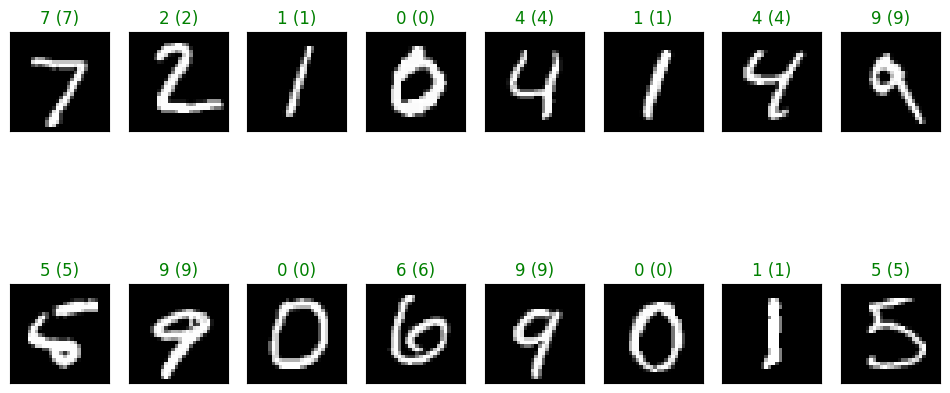

In [2]:
# %% [markdown]
# ## 基础神经网络实践：MNIST手写数字识别
# 使用PyTorch实现最简单的多层感知机（MLP）

# %% [code]
# 1. 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 检查GPU可用性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# %% [code]
# 2. 数据加载与预处理
transform = transforms.Compose([
    transforms.ToTensor(),         # 转换为张量
    transforms.Normalize((0.5,), (0.5,))  # 归一化到[-1, 1]
])

# 加载数据集
train_dataset = datasets.MNIST(
    root='../data', 
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.MNIST(
    root='../data', 
    train=False,
    download=True,
    transform=transform
)

# 创建数据加载器
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

# %% [code]
# 3. 定义神经网络模型
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28*28, 128),  # 输入层到隐藏层
            nn.ReLU(),             # 激活函数
            nn.Linear(128, 10)      # 隐藏层到输出层
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

model = SimpleMLP().to(device)
print(model)  # 打印模型结构

# %% [code]
# 4. 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# %% [code]
# 5. 训练模型
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 反向传播与优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

# %% [code]
# 6. 测试模型准确率
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy: {100 * correct / total:.2f}%')

# %% [code]
# 7. 可视化预测结果（展示前16个测试样本）
import numpy as np

# 获取测试批次数据
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# 预测
outputs = model(images)
_, preds = torch.max(outputs, 1)

# 转换图像格式
images = images.cpu().numpy()
images = images * 0.5 + 0.5  # 反归一化

# 绘制结果
fig = plt.figure(figsize=(12, 6))
for idx in np.arange(16):
    ax = fig.add_subplot(2, 8, idx+1, xticks=[], yticks=[])
    ax.imshow(images[idx].squeeze(), cmap='gray')
    ax.set_title(f"{preds[idx].item()} ({labels[idx].item()})", 
                 color=("green" if preds[idx]==labels[idx] else "red"))
plt.show()